# Figure 2 Comparing different pruning methods against independent in-vitro data validates CPC

In [15]:
import numpy as np 
import pandas
import conntility as conn
import os
import connalysis
import tqdm

from connalysis.network import classic as nxc

from scipy.spatial import distance
from scipy.spatial.distance import pdist, squareform
from matplotlib import pyplot as plt

In [2]:
# Connectivity matrix to use
root_path = "/Users/natali_obi_account/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/conn_matrix/"
fn_mat = root_path + "Human_NEWfunct_conmat_filtered_compressed.h5"
M = conn.ConnectivityMatrix.from_h5(fn_mat)

## Patch sample and analysis helpers

Functions to patch sample and evaluate triads and connection probabilities

In [3]:
def partition_model_into_subvolumes(M, decomposition_plane, decomposition_sz, min_column_sz):
    grps = conn.circuit_models.neuron_groups.group_by_grid(M.vertices, decomposition_plane, decomposition_sz)
    grps = grps.groupby("grid-subtarget")["node_ids"].apply(list)

    Ms = []
    for grp in grps:
        m = M.subpopulation(grp)
        if len(m) > min_column_sz:
            Ms.append(m)
    return Ms

In [4]:
col_slc = ["slice_x", "slice_y"]

def number_expected_er(P, N):
    from connalysis.network.topology import triad_combinations
    from scipy.stats import binom
    num_edge_per_triad = np.array([2, 2, 2, 3, 3, 3, 3, 4, 4 ,4 ,4, 5, 6])
    num_edge_per_non_triad = np.array([0, 1, 2])
    non_triad_combinations = np.array([1, 6, 3])

    p_er = triad_combinations * (P ** num_edge_per_triad) * ((1 - P) ** (6 - num_edge_per_triad))
    p_er_non = non_triad_combinations * (P ** num_edge_per_non_triad) * ((1 - P) ** (6 - num_edge_per_non_triad))
    assert np.abs(1 - (p_er.sum() + p_er_non.sum())) < 1E-6

    distr_er = binom(N, (p_er / p_er.sum()))
    return distr_er.mean(), distr_er.std()

def sample_and_count_triads(m, mv_cv, n_patch=12, n_samples=25, slice_thickness=150):
    counts = []
    sum_pairs = 0
    sum_connected = 0
    sum_rc = 0
    delta_rec = []
    delta_con = []
    delta_unc = []
    for _ in tqdm.tqdm(range(n_samples)):
        try:
            s = m.slice(np.random.rand() * np.pi, (np.random.rand() - 0.5) * 50, slice_thickness)
            s = s.patch_sample(n_patch, [0, 0], mv_cv, columns_xy=col_slc)
            sum_pairs += (len(s) * (len(s) - 1))
            sum_connected += s.matrix.nnz
            sum_rc += s.to_reciprocal().matrix.nnz
            counts.append(connalysis.network.topology.count_triads_fully_connected(s.matrix > 0, return_normalized=False))
            D = s.vertices[col_slc].values.reshape((1, -1, 2)) - s.vertices[col_slc].values.reshape((-1, 1, 2))
            delta_rec.append(pandas.DataFrame(
                D[(s.array > 0) & (s.array.transpose() > 0)], columns=["horizontal", "vertical"]
            ))
            delta_con.append(pandas.DataFrame(
                D[(s.array > 0) & (s.array.transpose() == 0)], columns=["horizontal", "vertical"]
            ))
            delta_unc.append(pandas.DataFrame(
                D[(s.array == 0)], columns=["horizontal", "vertical"]
            ))
        except:
            pass
    P = sum_connected / sum_pairs
    Prec = sum_rc / sum_pairs
    deltas = pandas.concat([
        pandas.concat(delta_rec, axis=0, names=["sample"], keys=range(len(delta_rec))),
        pandas.concat(delta_con, axis=0, names=["sample"], keys=range(len(delta_con))),
        pandas.concat(delta_unc, axis=0, names=["sample"], keys=range(len(delta_unc)))
    ], axis=0, keys=["reciprocal", "unidirectional", "unconnected"])
    counts = np.vstack(counts).sum(axis=0)
    return counts, (P, Prec), deltas


Main entry point

In [5]:
def execute_slice_and_patch_campaign(M, param_dict):
    if "decomposition_plane" in param_dict:
        Ms = partition_model_into_subvolumes(M, param_dict["decomposition_plane"],
                                             param_dict["decomposition_sz"], param_dict["min_column_sz"])
    else:
        Ms = [M]
    
    all_counts = []
    all_er = []
    all_deltas = []

    mv_cv = np.array(param_dict["mv_cv"])
    patch_kwargs = param_dict["patch_kwargs"]
    allP_u = []; allP_rc = []
    for m in Ms:
        counts, P, deltas = sample_and_count_triads(m, mv_cv, **patch_kwargs)
        allP_u.append(P[0]); allP_rc.append(P[1])
        count_er_mn, count_er_sd = number_expected_er(P[0], counts.sum())
        all_counts.append((counts - count_er_mn) / count_er_sd)
        all_deltas.append(deltas)

    all_counts = pandas.DataFrame(all_counts,
                     index=pandas.RangeIndex(len(all_counts), name="subvolume"),
                     columns=pandas.RangeIndex(13, name="motif"))
    all_deltas = pandas.concat(all_deltas, axis=0, names=["subvolume"], keys=range(len(all_deltas)))
    return all_counts, all_deltas, pandas.DataFrame({"unidirectional": allP_u,
                                                     "reciprocal": allP_rc})
  

## Patch-clamp experiment

In [6]:
campaign_cfg = {
    "decomposition_plane": ["x", "z"], # What are the horizontal axes of the volume?Decomposition will happen in this plane.
    "decomposition_sz": 250,
    "min_column_sz": 500, # After decomposition, columns smaller than this will be discarded,
    "mv_cv": [[145**2, 0], [0, 150**2]], # Describes the patch sampling spatial dimensions. 40 ** 2 will sample neuron pairs up to ~100 um.
    "patch_kwargs": {
        "slice_thickness": 200,
        "n_samples": 55, # The number of times the patch sampling procedure will be applied
        "n_patch": 12 # Up to this number of neurons will be sampled together
    }
}

all_counts, all_deltas, P = execute_slice_and_patch_campaign(M, campaign_cfg)

 24%|███████████████████▌                                                               | 13/55 [00:00<00:00, 63.75it/s]

Testing 12 potential triadic pairs
Time spent finding triads: 0.0003535747528076172
Found 12 connected triads
Time spent classifying triads: 0.0002391338348388672
Testing 17 potential triadic pairs
Time spent finding triads: 0.00012683868408203125
Found 18 connected triads
Time spent classifying triads: 0.00014901161193847656
Testing 11 potential triadic pairs
Time spent finding triads: 0.00011897087097167969
Found 11 connected triads
Time spent classifying triads: 9.775161743164062e-05
Testing 37 potential triadic pairs
Time spent finding triads: 0.0001480579376220703
Found 42 connected triads
Time spent classifying triads: 0.0003180503845214844
Testing 39 potential triadic pairs
Time spent finding triads: 0.00014066696166992188
Found 49 connected triads
Time spent classifying triads: 0.0003619194030761719
Testing 57 potential triadic pairs
Time spent finding triads: 0.00017309188842773438
Found 95 connected triads
Time spent classifying triads: 0.0007050037384033203
Testing 61 potent

 49%|████████████████████████████████████████▋                                          | 27/55 [00:00<00:00, 65.62it/s]

Testing 52 potential triadic pairs
Time spent finding triads: 0.00021505355834960938
Found 76 connected triads
Time spent classifying triads: 0.0007519721984863281
Testing 55 potential triadic pairs
Time spent finding triads: 0.00018405914306640625
Found 76 connected triads
Time spent classifying triads: 0.0005550384521484375
Testing 50 potential triadic pairs
Time spent finding triads: 0.0001590251922607422
Found 59 connected triads
Time spent classifying triads: 0.00043892860412597656
Testing 45 potential triadic pairs
Time spent finding triads: 0.0001499652862548828
Found 56 connected triads
Time spent classifying triads: 0.0004029273986816406
Testing 41 potential triadic pairs
Time spent finding triads: 0.00015091896057128906
Found 50 connected triads
Time spent classifying triads: 0.0003662109375
Testing 37 potential triadic pairs
Time spent finding triads: 0.00015020370483398438
Found 40 connected triads
Time spent classifying triads: 0.0002980232238769531
Testing 59 potential tr

 75%|█████████████████████████████████████████████████████████████▊                     | 41/55 [00:00<00:00, 65.07it/s]

...

Testing 48 potential triadic pairs
Time spent finding triads: 0.00021910667419433594
Found 56 connected triads
Time spent classifying triads: 0.0005631446838378906
Testing 27 potential triadic pairs
Time spent finding triads: 0.00013208389282226562
Found 25 connected triads
Time spent classifying triads: 0.00019502639770507812
Testing 66 potential triadic pairs
Time spent finding triads: 0.0001919269561767578
Found 114 connected triads
Time spent classifying triads: 0.0008137226104736328
Testing 65 potential triadic pairs
Time spent finding triads: 0.0001900196075439453
Found 112 connected triads
Time spent classifying triads: 0.0008318424224853516
Testing 60 potential triadic pairs
Time spent finding triads: 0.00022101402282714844
Found 85 connected triads
Time spent classifying triads: 0.0007390975952148438
Testing 48 potential triadic pairs
Time spent finding triads: 0.00015401840209960938
Found 52 connected triads
Time spent classifying triads: 0.0004012584686279297
Testing 59 pote

 85%|██████████████████████████████████████████████████████████████████████▉            | 47/55 [00:00<00:00, 70.23it/s]

Testing 10 potential triadic pairs
Time spent finding triads: 0.00015497207641601562
Found 12 connected triads
Time spent classifying triads: 0.00024080276489257812
Testing 54 potential triadic pairs
Time spent finding triads: 0.0001609325408935547
Found 63 connected triads
Time spent classifying triads: 0.0004596710205078125
Testing 54 potential triadic pairs
Time spent finding triads: 0.00019788742065429688
Found 71 connected triads
Time spent classifying triads: 0.0006687641143798828
Testing 16 potential triadic pairs
Time spent finding triads: 0.00012493133544921875
Found 14 connected triads
Time spent classifying triads: 0.00011897087097167969
Testing 9 potential triadic pairs
Time spent finding triads: 0.00011205673217773438
Found 9 connected triads
Time spent classifying triads: 8.273124694824219e-05
Testing 22 potential triadic pairs
Time spent finding triads: 0.00016307830810546875
Found 31 connected triads
Time spent classifying triads: 0.00037407875061035156
Testing 8 potent

100%|███████████████████████████████████████████████████████████████████████████████████| 55/55 [00:00<00:00, 70.23it/s]

Testing 28 potential triadic pairs
Time spent finding triads: 0.0001780986785888672
Found 30 connected triads
Time spent classifying triads: 0.0004189014434814453


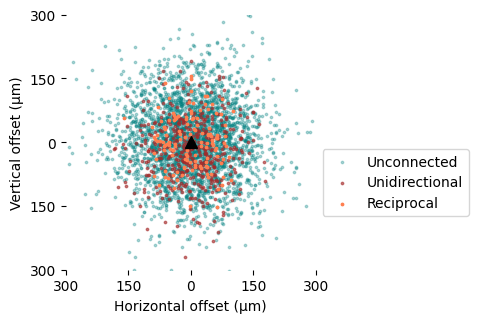

In [7]:
i = 0
d = all_deltas.loc[i]
d["distance"] = np.linalg.norm(d, axis=1)
dists = d.reset_index().groupby("level_0")["distance"].mean()

fig = plt.figure(figsize=(5, 3))
ax = fig.add_axes([0.1, 0.1, 0.5, 0.85])

def sample_random_fraction(arr_in, frac):
    assert frac <= 1
    b = np.random.choice(len(arr_in), int(len(arr_in) * frac), replace=False)
    return arr_in.iloc[b]["horizontal"], arr_in.iloc[b]["vertical"]

cols_use = [[0.6, 0.6, 1.0], [0.1, 0.1, 0.7], [0.9, 0.3, 0.0]]

ax.scatter(*sample_random_fraction(d.loc["unconnected"], 0.5), color='teal', s=3, alpha=0.3, label="Unconnected")
ax.scatter(*sample_random_fraction(d.loc["unidirectional"], 0.5), color='brown', s=3, alpha=0.6, label="Unidirectional")
ax.scatter(*sample_random_fraction(d.loc["reciprocal"], 0.5), color='coral', s=3, alpha=1., label="Reciprocal")
ax.plot(0, 0, marker="^", ms=8, color="black")
ax.set_xlabel("Horizontal offset (µm)")
ax.set_ylabel("Vertical offset (µm)")
ax.set_frame_on(False)
# plt.axis("equal")
ax.set_xlim([-300, 300]); ax.set_xticks([-300, -150, 0, 150, 300]); ax.set_xticklabels([300, 150, 0, 150, 300])
ax.set_ylim([-300, 300]); ax.set_yticks([-300, -150, 0, 150, 300]); ax.set_yticklabels([300, 150, 0, 150, 300])
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
#plt.savefig('patch_clamp_sampling.svg')

Text(0, 0.5, 'Mean distance (µm)')

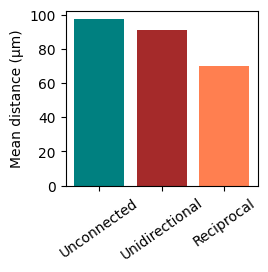

In [8]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_axes([0.725, 0.35, 0.275, 0.35])
ax.bar(2, dists["reciprocal"], color='coral')
ax.bar(1, dists["unidirectional"], color='brown')
ax.bar(0, dists["unconnected"], color='teal')
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["Unconnected", "Unidirectional", "Reciprocal"], rotation=35)
ax.set_ylabel("Mean distance (µm)")
#ax.set_frame_on(False)
#plt.savefig('patch_clamp_sampling_barplot.svg')

### Recreating Peng et al 2024 figure 1.B

In [9]:
Peng_values = [0.158102766798419, 0.02661396574440053, 0.024769433465085616] #, 0.032411067193675897]
Peng_labels = ['unidirectionla data', 'reciprocal data', 'reciprocal ER'] #, 'reciprocal het ER']

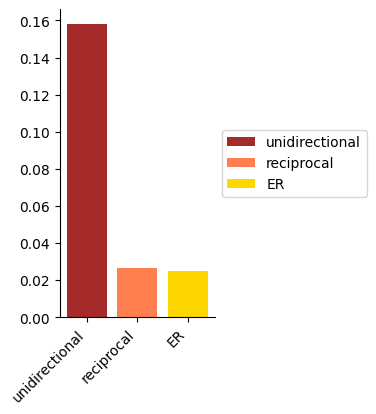

In [11]:
x = [1, 2, 3]
colors = ['brown', 'coral', 'gold']
labels = ['unidirectional', 'reciprocal', 'ER']
plt.figure(figsize=(2,4))
#remove frame from each side of plot
#plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
#plt.rcParams['axes.spines.bottom'] = False

plt.bar(x, Peng_values, color=colors, label=labels, width=0.8)

plt.xticks(x, labels)
plt.xticks(rotation=45, ha="right")
#plt.axis('off')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

#plt.savefig('bar_plot_Peng.svg')

### Validate connection probabilites for all connectivity matrices: functional, E_to_T, T_to_T, E_to_E and T_to_E 
To be compared to Peng et al., Figure 1B (dashed lines)

In [12]:
# Loading connectivity matrices

fns = {
    "Functional_human": root_path + "Human_NEWfunct_conmat_filtered_compressed.h5",
    "E_to_T_human": root_path + "Human_pruned_E_to_T_conmat.h5",
    "T_to_T_human": root_path + "Human_pruned_T_to_T_conmat.h5",
    "E_to_E_human": root_path + "Human_pruned_E_to_E_conmat.h5",
    "T_to_E_human": root_path + "Human_pruned_T_to_E_conmat.h5"
}

Ms = dict([(k, conn.ConnectivityMatrix.from_h5(v))
           for k, v in fns.items()])

#### Sampling at scales that resemble Peng et al (see above).

In [13]:
def patch_result_to_con_probs(deltas):
    deltas = deltas[(deltas != 0).any(axis=1)]

    tst = deltas.reset_index().groupby("subvolume")["level_1"].value_counts().unstack("level_1")
    tst["connected"] = tst["reciprocal"] + tst["unidirectional"]
    tst["reciprocal_pairs"] = tst["reciprocal"] / 2 # Because the original analysis counts rc pairs twice, once for each direction
    tst["sorted_pairs"] = tst["connected"] + tst["unconnected"]
    tst["pairs"] = tst["sorted_pairs"] / 2

    count_srt = int(tst["sorted_pairs"][0]) # All samplings have the same number. Just using the first.
    count_unsrt = int(tst["pairs"][0])
    
    return tst, count_srt, count_unsrt

campaign_cfg = {
    "decomposition_plane": ["x", "z"], # What are the horizontal axes of the volume?Decomposition will happen in this plane.
    "decomposition_sz": 250,
    "min_column_sz": 500, # After decomposition, columns smaller than this will be discarded,
    "mv_cv": [[145**2, 0], [0, 150**2]], # Describes the patch sampling spatial dimensions. 40 ** 2 will sample neuron pairs up to ~100 um.
    "patch_kwargs": {
        "slice_thickness": 200,
        "n_samples": 55, # The number of times the patch sampling procedure will be applied
        "n_patch": 12 # Up to this number of neurons will be sampled together
    }
}

df_Ps = []; counts_srt = []; counts_unsrt = []
for k, M in Ms.items():
    counts, deltas, P = execute_slice_and_patch_campaign(M, campaign_cfg)
    df_P, c_srt, c_un = patch_result_to_con_probs(deltas)
    df_Ps.append((k, df_P)); counts_srt.append((k, c_srt)); counts_unsrt.append((k, c_un))
df_Ps = dict(df_Ps); counts_srt = dict(counts_srt); counts_unsrt = dict(counts_unsrt)

 25%|█████████████████████▏                                                             | 14/55 [00:00<00:00, 67.02it/s]

Testing 44 potential triadic pairs
Time spent finding triads: 0.00022602081298828125
Found 52 connected triads
Time spent classifying triads: 0.0005471706390380859
Testing 54 potential triadic pairs
Time spent finding triads: 0.00017213821411132812
Found 77 connected triads
Time spent classifying triads: 0.0005629062652587891
Testing 32 potential triadic pairs
Time spent finding triads: 0.00013589859008789062
Found 38 connected triads
Time spent classifying triads: 0.0002980232238769531
Testing 36 potential triadic pairs
Time spent finding triads: 0.00013899803161621094
Found 32 connected triads
Time spent classifying triads: 0.0002448558807373047
Testing 61 potential triadic pairs
Time spent finding triads: 0.00017189979553222656
Found 87 connected triads
Time spent classifying triads: 0.0006520748138427734
Testing 44 potential triadic pairs
Time spent finding triads: 0.00014829635620117188
Found 58 connected triads
Time spent classifying triads: 0.0004420280456542969
Testing 17 poten

 51%|██████████████████████████████████████████▎                                        | 28/55 [00:00<00:00, 67.56it/s]

Testing 39 potential triadic pairs
Time spent finding triads: 0.00022411346435546875
Found 39 connected triads
Time spent classifying triads: 0.0005619525909423828
Testing 52 potential triadic pairs
Time spent finding triads: 0.00017213821411132812
Found 57 connected triads
Time spent classifying triads: 0.0004260540008544922
Testing 66 potential triadic pairs
Time spent finding triads: 0.0002040863037109375
Found 165 connected triads
Time spent classifying triads: 0.001161813735961914
Testing 14 potential triadic pairs
Time spent finding triads: 0.00011801719665527344
Found 12 connected triads
Time spent classifying triads: 0.00010585784912109375
Testing 65 potential triadic pairs
Time spent finding triads: 0.00019502639770507812
Found 137 connected triads
Time spent classifying triads: 0.0009698867797851562
Testing 54 potential triadic pairs
Time spent finding triads: 0.00015616416931152344
Found 64 connected triads
Time spent classifying triads: 0.0004658699035644531
Testing 34 pote

 76%|███████████████████████████████████████████████████████████████▍                   | 42/55 [00:00<00:00, 68.34it/s]

...

Time spent classifying triads: 0.0012688636779785156
Testing 10 potential triadic pairs
Time spent finding triads: 0.0001380443572998047
Found 10 connected triads
Time spent classifying triads: 0.00013208389282226562
Testing 2 potential triadic pairs
Time spent finding triads: 0.0001239776611328125
Found 2 connected triads
Time spent classifying triads: 3.600120544433594e-05
Testing 9 potential triadic pairs
Time spent finding triads: 0.00011682510375976562
Found 9 connected triads
Time spent classifying triads: 8.702278137207031e-05
Testing 32 potential triadic pairs
Time spent finding triads: 0.00014710426330566406
Found 35 connected triads
Time spent classifying triads: 0.0002810955047607422
Testing 32 potential triadic pairs
Time spent finding triads: 0.00016689300537109375
Found 32 connected triads
Time spent classifying triads: 0.0004298686981201172
Testing 15 potential triadic pairs
Time spent finding triads: 0.00011706352233886719
Found 15 connected triads
Time spent classifyin

 84%|█████████████████████████████████████████████████████████████████████▍             | 46/55 [00:00<00:00, 72.52it/s]

Time spent classifying triads: 0.0011439323425292969
Testing 18 potential triadic pairs
Time spent finding triads: 0.00014281272888183594
Found 16 connected triads
Time spent classifying triads: 0.00013899803161621094
Testing 32 potential triadic pairs
Time spent finding triads: 0.00015091896057128906
Found 36 connected triads
Time spent classifying triads: 0.0002942085266113281
Testing 42 potential triadic pairs
Time spent finding triads: 0.00016808509826660156
Found 44 connected triads
Time spent classifying triads: 0.00034809112548828125
Testing 3 potential triadic pairs
Time spent finding triads: 0.00011777877807617188
Found 3 connected triads
Time spent classifying triads: 4.601478576660156e-05


100%|███████████████████████████████████████████████████████████████████████████████████| 55/55 [00:00<00:00, 70.30it/s]

Testing 43 potential triadic pairs
Time spent finding triads: 0.00019598007202148438
Found 46 connected triads
Time spent classifying triads: 0.0004429817199707031
Testing 28 potential triadic pairs
Time spent finding triads: 0.00013375282287597656
Found 24 connected triads
Time spent classifying triads: 0.00020194053649902344
Testing 48 potential triadic pairs
Time spent finding triads: 0.00018715858459472656
Found 66 connected triads
Time spent classifying triads: 0.0005171298980712891
Testing 55 potential triadic pairs
Time spent finding triads: 0.00017523765563964844
Found 70 connected triads
Time spent classifying triads: 0.0005309581756591797
Testing 30 potential triadic pairs
Time spent finding triads: 0.0001418590545654297
Found 38 connected triads
Time spent classifying triads: 0.0003058910369873047


Total reciprocal over-/under-expression without sampling

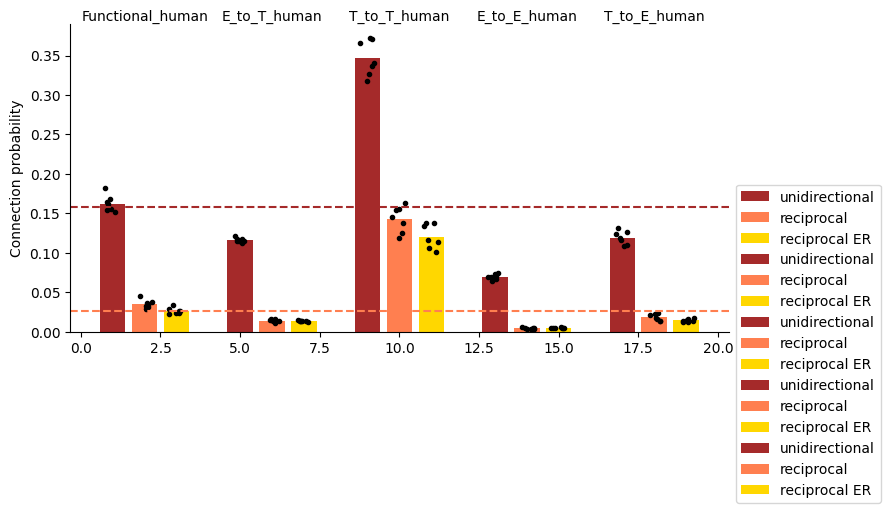

In [14]:
fig = plt.figure(figsize=(1.5 * len(df_Ps) + 1, 4))
low_bars = [0,0,0,0,0]
i = 1
xticks = []; xticklbls = []; ttls = []
for k, df_P in df_Ps.items():
    ax = fig.gca()

    x = 0.5 * (np.random.rand(len(df_P)) - 0.5) + 0 + i
    y = df_P["connected"].sum() / df_P["sorted_pairs"].sum()
    mn = int(df_P["connected"].mean()); sd = int(df_P["connected"].std())
    ax.bar(i, y, color="brown", label="unidirectional")
    #ax.errorbar(i, y, yerr = sd/df_P["pairs"].sum(), alpha=0.5, fmt=" ", capsize=6, elinewidth=3, color='black')

    ax.plot(x, df_P["connected"] / df_P["sorted_pairs"], marker='.', color="black", ls="None")
    #ax.text(i + 0.25, y + 0.01, "{0}+-{1}/{2}".format(mn, sd, count))

    x = 0.5 * (np.random.rand(len(df_P)) - 0.5) + 1 + i
    y = df_P["reciprocal_pairs"].sum() / df_P["pairs"].sum()
    mn = int(df_P["reciprocal_pairs"].mean()); sd = int(df_P["reciprocal_pairs"].std())
    ax.bar(i + 1, y, color="coral", label="reciprocal")
    #ax.errorbar(i+1, y, yerr = sd/df_P["pairs"].sum(), alpha=0.5, fmt=" ", capsize=6, elinewidth=3, color='black')

    ax.plot(x, df_P["reciprocal_pairs"] / df_P["pairs"], marker='.', color="black", ls="None")
    #ax.text(i + 1.25, y + 0.01, "{0}+-{1}/{2}".format(mn, sd, count_b))

    x = 0.5 * (np.random.rand(len(df_P)) - 0.5) + 2 + i
    y = (df_P["connected"].sum() / df_P["sorted_pairs"].sum()) ** 2
    smpls = df_P["pairs"] * (df_P["connected"] / df_P["sorted_pairs"]) ** 2
    mn = int(smpls.mean()); sd = int(smpls.std())
    ax.bar(i + 2, y, color="gold", label="reciprocal ER")
    #ax.errorbar(i+2, y, yerr = sd/df_P["pairs"].sum(), alpha=0.5, fmt=" ", capsize=6, elinewidth=3, color='black')

    ax.plot(x, (df_P["connected"] / df_P["sorted_pairs"]) ** 2, marker='.', color="black", ls="None")
    # ax.text(2.25, y + 0.01, "{0}+-{1}/{2}".format(mn, sd, count_b))
    
    xticks.extend([i, i + 1, i + 2])
    #xticklbls.extend(["unidirectional", "reciprocal", "reciprocal ER"])
    ttls.append(k)
    i = i + 4

#ax.set_xticks(xticks); ax.set_xticklabels(xticklbls, rotation=45)
#ax.set_frame_on(False)
ax.spines[['right', 'top']].set_visible(False)
ax.set_ylabel("Connection probability")
ax.set_xlim(ax.get_xlim())
ax.plot(ax.get_xlim(), [0.158102766798419, 0.158102766798419], color="brown", ls="--")
ax.plot(ax.get_xlim(), [0.02661396574440053, 0.02661396574440053], color="coral", ls="--")

ax.legend(loc='upper left', bbox_to_anchor=(1, 0.5))

ymx = ax.get_ylim()[1]
for _ttl, _x in zip(ttls, xticks[1::3]):
    ax.text(_x, ymx, _ttl, horizontalalignment="center", verticalalignment="bottom")
    
#plt.savefig('Connection_Probability_ours_vs_Peng.svg')